<a href="https://colab.research.google.com/github/jd4068/Hydra_Connectome/blob/main/code/Code_DynamicModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
#read csv
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Yuste_Paper_Figures/summed_celltypes.csv')
df.head()
#into matrix
#make frist column the idnex
df = df.set_index(df.columns[0])
df.head()
df.shape
# -------------------------------
# 1. Load your own recurrent network matrix
# -------------------------------
W = df
N = W.shape[0]
gain = 1.3  # optional global scaling factor

# optional: normalize so largest eigenvalue = gain
W *= gain / np.max(np.abs(np.linalg.eigvals(W))).real

# activation function
def phi(x):
    return np.tanh(x)

def step(x, dt=0.05):
    return x + dt * (-x + phi(W @ x))




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# activation function
def phi(x):
    return np.tanh(x)

# dynamics: dx/dt = -x + phi(Wx)
def step(x, dt=0.05):
    return x + dt * (-x + phi(W @ x))




In [ ]:
#load drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


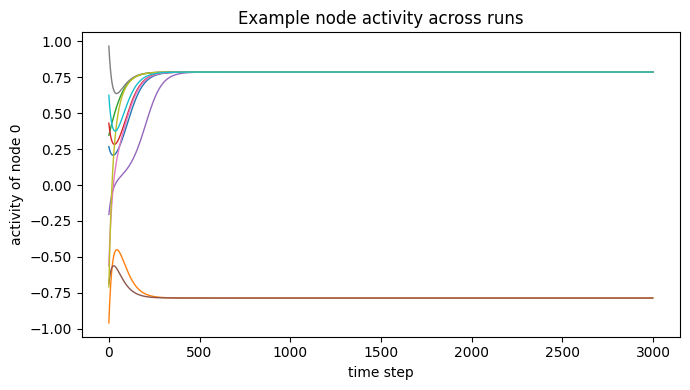

In [ ]:
# -------------------------------
# 2. Simulate from many initial conditions
# -------------------------------
T = 3000  # number of time steps
dt = 0.05
n_inits = 40  # how many different initial conditions

final_states = []
trajectories = []
rng = np.random.default_rng(0)
for i in range(n_inits):
    x = rng.uniform(-1, 1, N)
    traj = np.zeros((T, N))
    for t in range(T):
        x = step(x, dt)
        traj[t] = x
    trajectories.append(traj)
    final_states.append(x)

final_states = np.array(final_states)

# -------------------------------
# 3. Visualize multistability
# -------------------------------

# plot example time traces of one node from different inits
plt.figure(figsize=(7,4))
for i in range(min(n_inits, 10)):
    plt.plot(trajectories[i][:,0], lw=1)
plt.title('Example node activity across runs')
plt.xlabel('time step')
plt.ylabel('activity of node 0')
plt.tight_layout()
plt.show()

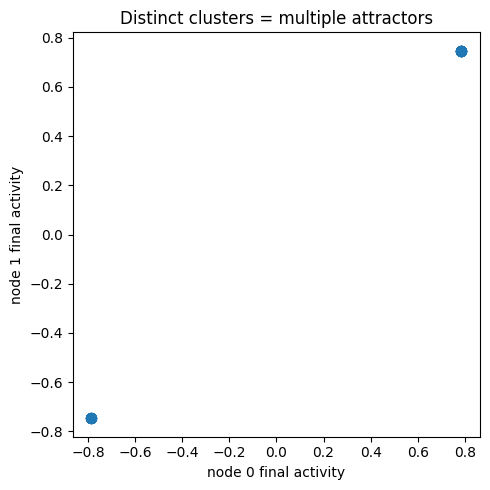

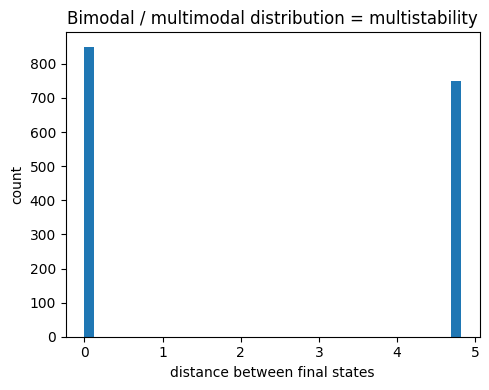

In [ ]:

# scatter plot of final states
plt.figure(figsize=(5,5))
if N >= 2:
    plt.scatter(final_states[:,0], final_states[:,1], s=50, alpha=0.7)
    plt.xlabel('node 0 final activity')
    plt.ylabel('node 1 final activity')
else:
    plt.hist(final_states[:,0], bins=30)
plt.title('Distinct clusters = multiple attractors')
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Simple measure: pairwise distance between final states
# -------------------------------
from numpy.linalg import norm
D = np.zeros((n_inits, n_inits))
for i in range(n_inits):
    for j in range(n_inits):
        D[i, j] = norm(final_states[i] - final_states[j])

plt.figure(figsize=(5,4))
plt.hist(D.flatten(), bins=40)
plt.xlabel('distance between final states')
plt.ylabel('count')
plt.title('Bimodal / multimodal distribution = multistability')
plt.tight_layout()
plt.show()

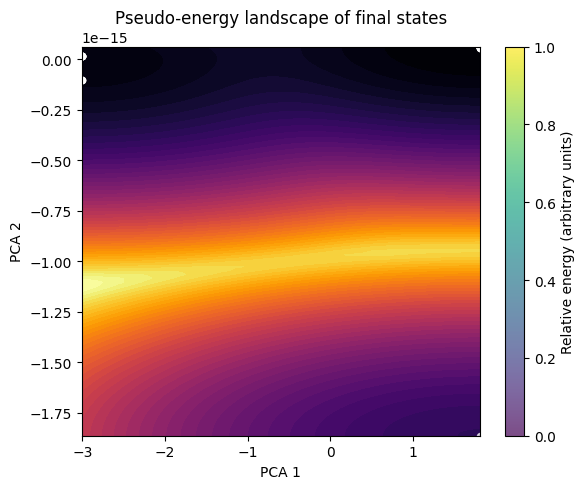

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# -------------------------------
# 6. Energy landscape approximation
# -------------------------------
# Project final states into PCA space (you already did this)
# proj = pca.fit_transform(final_states)

# Estimate a pseudo-energy based on local density (high density = low energy)
x, y = proj[:,0], proj[:,1]
# create grid
grid_x, grid_y = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]

# estimate density with Gaussian smoothing
from scipy.stats import gaussian_kde
kde = gaussian_kde(np.vstack([x, y]))
Z = kde(np.vstack([grid_x.ravel(), grid_y.ravel()])).reshape(grid_x.shape)

# Convert to pseudo-energy (negative log density)
E = -np.log(Z + 1e-6)

# Normalize for visualization
E = (E - E.min()) / (E.max() - E.min())

# Plot energy field
plt.figure(figsize=(6,5))
plt.contourf(grid_x, grid_y, E, levels=50, cmap='inferno')
plt.scatter(x, y, c='white', s=20, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Pseudo-energy landscape of final states')
plt.colorbar(label='Relative energy (arbitrary units)')
plt.tight_layout()
plt.show()


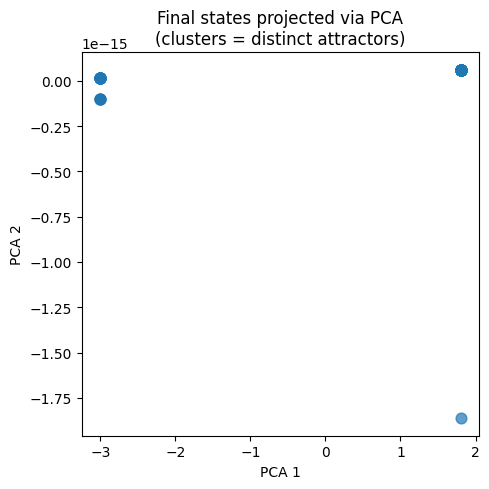

Explained variance by first 2 PCs: [1.00000000e+00 1.65941945e-32]


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------------
# 5. PCA visualization of all final states
# -------------------------------
# Each row in final_states = one final configuration across all nodes
pca = PCA(n_components=2)
proj = pca.fit_transform(final_states)  # project each final state into 2D

plt.figure(figsize=(5,5))
plt.scatter(proj[:,0], proj[:,1], s=60, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Final states projected via PCA\n(clusters = distinct attractors)')
plt.tight_layout()
plt.show()

# Optional: visualize explained variance
print("Explained variance by first 2 PCs:", pca.explained_variance_ratio_)


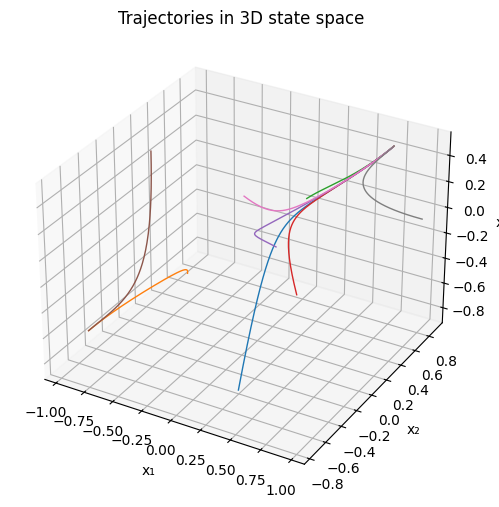

In [ ]:

from mpl_toolkits.mplot3d import Axes3D



def phi(x): return np.tanh(x)
def f(x): return -x + phi(W @ x)

dt = 0.05
T = 400
n_inits = 8
rng = np.random.default_rng(0)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

for i in range(n_inits):
    x = rng.uniform(-1, 1, N)
    traj = []
    for t in range(T):
        x = x + dt * f(x)
        traj.append(x.copy())
    traj = np.array(traj)
    ax.plot(traj[:,0], traj[:,1], traj[:,2], lw=1)

ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('x₃')
ax.set_title('Trajectories in 3D state space')
plt.show()

